# Insurance Dataset - Preprocessing Assignment


## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## 2. Load the Dataset


In [3]:
df = pd.read_csv('insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Check Data Types and Number of Unique Values


In [4]:
def chk_types_table(data):
    return pd.DataFrame({
        'Dtype': data.dtypes,
        'Num_Unique': data.nunique()
    }).T

chk_types_table(df)


,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
Num_Unique,47,2,548,6,2,4,1337


### Convert categorical columns to `category`


In [5]:
cat_cols = df.select_dtypes('object').columns
df[cat_cols] = df[cat_cols].astype('category')
chk_types_table(df)


,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,int64,category,category,float64
Num_Unique,47,2,548,6,2,4,1337


## 4. Check Missing Values


In [6]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100
pd.DataFrame({'Null': null, 'ratio %': ratio}).T


,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Result:** No missing values were found in this dataset, so no imputation or row deletion is required.


## 5. Handle Outliers


### Check for Outliers using Boxplots


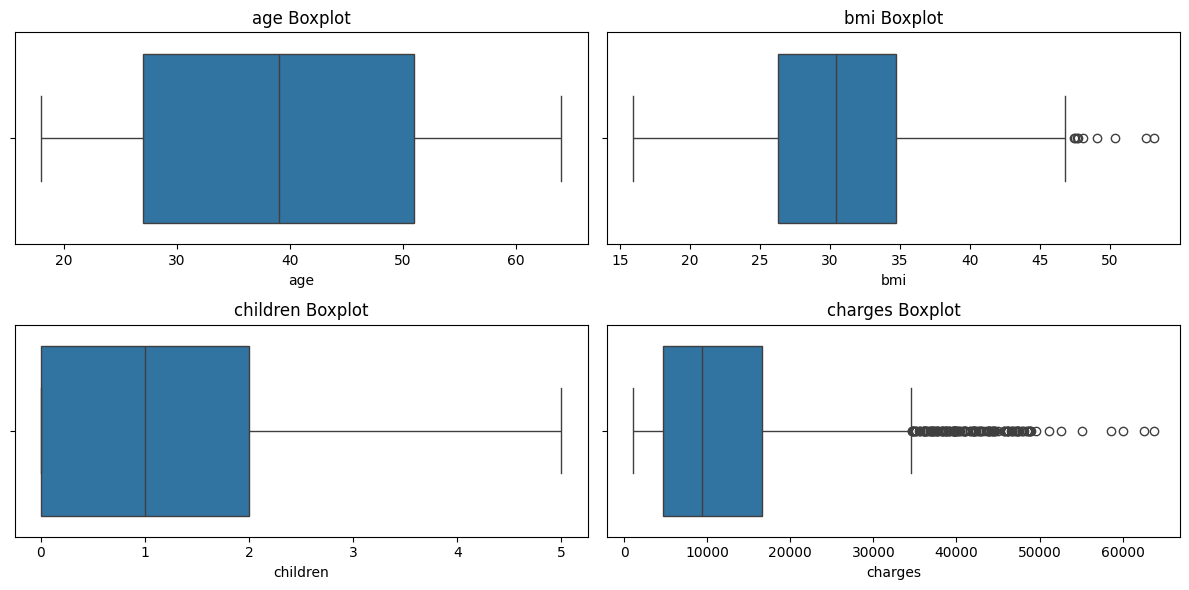

In [7]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()


### Apply IQR Method and Cap Outliers


In [8]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_Fence = Q1 - 1.5 * IQR
    Upper_Fence = Q3 + 1.5 * IQR

    df[col] = df[col].clip(Lower_Fence, Upper_Fence)

df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Check Boxplots After Outlier Treatment


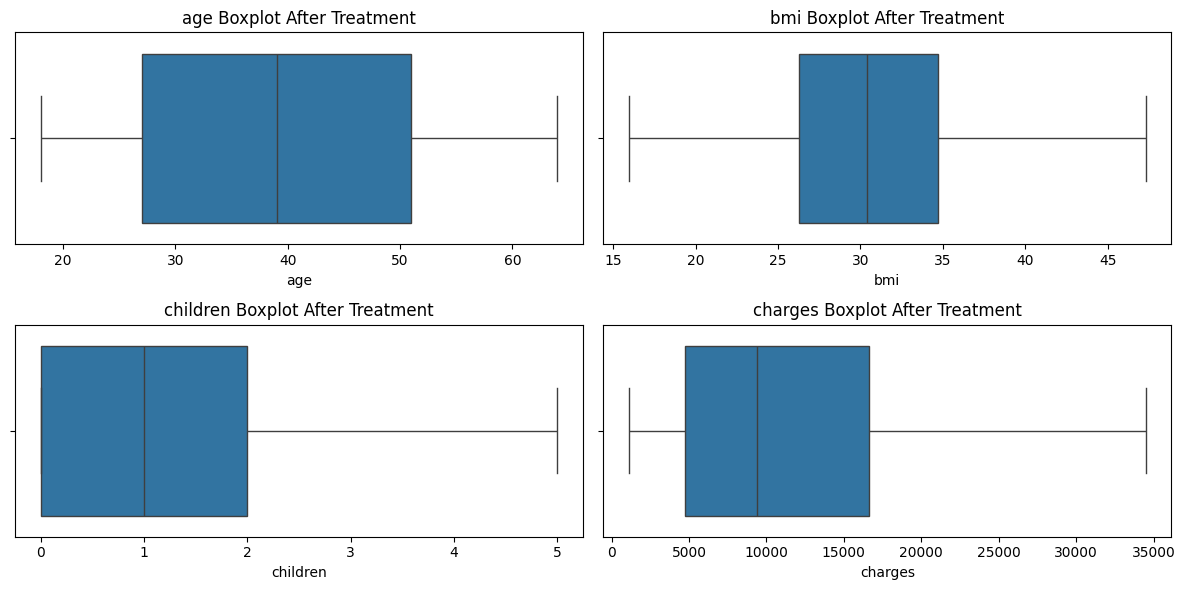

In [9]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot After Treatment')
plt.tight_layout()
plt.show()


## 6. Check and Remove Duplicates


In [10]:
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Duplicates after:', df.duplicated().sum())


Duplicates before: 1
Duplicates after: 0


## 7. Final Check


In [11]:
print('Final shape:', df.shape)
df.info()
df.head()


Final shape: (1337, 7)
<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.3 KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 8. Save the Preprocessed Dataset


In [12]:
df.to_csv('insurance_preprocessed.csv', index=False)
print('Preprocessed dataset saved successfully.')


Preprocessed dataset saved successfully.
